# Experiment on simulations n°4 - Practical issues (see Section 5.1.5)

## Outline

[Content](#content)

[Prerequisite packages and settings](#prerequisite-packages-and-settings)

[I- Impact of PoIs in leakage model extraction](#exp-1)

- [Step 1: Traces generation](#exp-1-step-1)

- [Step 2: Instanciation of a cVAE-OSM model](#exp-1-step-2)

- [Step 3: Training of cVAE-OSM model](#exp-1-step-3)

- [Step 4: Visualization of leakage models extracted by the model](#exp-1-step-4)

[II- Impact of $D$ in cVAE-OSM weights convergence](#exp-2)

- [Step 1: Traces generation](#exp-2-step-1)

- [Step 2: Instanciation of a cVAE-OSM model](#exp-2-step-2)

- [Step 3: Training of cVAE-OSM model](#exp-2-step-3)

- [Step 4: Visualization of leakage models extracted by the model](#exp-2-step-4)

[III- Impact of basis size](#exp-3)

- [Step 1: Traces generation](#exp-3-step-1)

- [Step 2: Instanciation of a cVAE-OSM model](#exp-3-step-2)

- [Step 3: Training of cVAE-OSM model](#exp-3-step-3)

- [Step 4: Visualization of leakage models extracted by the model](#exp-3-step-4)

## Content <a class='anchor' id='content'></a>

In this notebook, we propose to conduct the last experiments of our paper (see Section 5.1.5), in which we assess practical impacts on the convergence of cVAE-OSM weights.

We thus conduct in this notebook three different experiments. More specifically, we evaluate here the impact of the number of points of interest (PoIs), the number of samples $D$ and the basis size on cVAE-OSM weights convergence.

To do so, for each experiment, we first generate traces. Then, we instanciate and train a cVAE-OSM model. Finally, according to parameters estimated by our model, we evaluate its weights convergence.

## Prerequisite packages and settings <a class='anchor' id='prerequisite-packages-and-settings'></a>

Here are the Python packages and settings needed to run properly this notebook.

In [1]:
from cvae_osm_utils.generate_traces import *
from cvae_osm_utils.cVAE_OSM_model import *
from cvae_osm_utils.cVAE_OSM_tools import *
from matplotlib import pyplot as plt

# Enables Tensorflow program to run deterministically for reproducible results
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

plt.rcParams['text.usetex'] = True

## Impact of PoIs in leakage model extraction <a class='anchor' id='exp-1'></a>

The aim of this experiment is to assess the impact of PoIs in leakage model extraction. To do so, we generate traces in which all samples are PoIs. Then, we create and train a cVAE-OSM model.

Finally, we assess cVAE-OSM leakage model extraction by visualizing leakage models $\hat{\Psi}_\phi$ and $\hat{\Psi}_\theta$ extracted by the model and computing mean squared errors (MSE) for both estimated leakage models. 

Regarding $\boldsymbol{\Sigma}_\phi$, we compute mean approximation error to evaluate its convergence.

### Step 1: Traces generation <a class='anchor' id='exp-1-step-1'></a>

The generation of traces is done using a function called $\texttt{generate\_traces}$, available in $\texttt{generate\_traces.py}$ file. 

In the following example, we generate $20,000$ traces of $1,000$ samples such that all samples are PoIs. We consider the fourth scenario with a isotropic Gaussian noise of parameters $\mu=0$ and $\sigma=5$.
The targeted byte is $0$ and the key is fixed. We set the seed to $42$ to have reproductible results. 

In [2]:
# Traces generation
targeted_byte = 0

traces, plaintexts, keys, targeted_variables, sigmas = generate_traces(nb_traces=20000, nb_samples=1000, nb_poi=1000, mu=0, sigmas=np.array([5]), targeted_byte=targeted_byte, \
                        isotropic_noise=True, scenario='scenario_4', key_fixed=True, seed=42)

print("Traces generated \U00002705")

Traces generated ✅


Here is an example of generated traces.

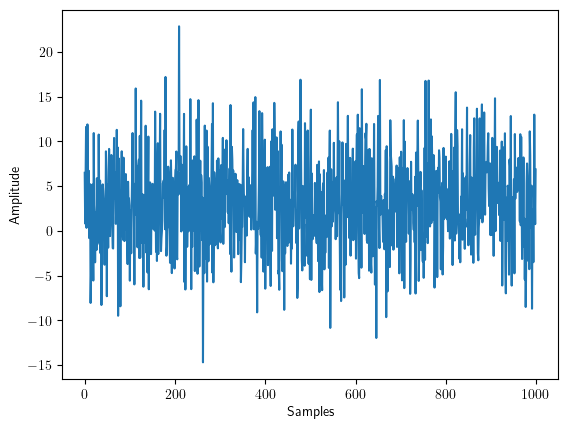

In [3]:
# Plot of a trace
plt.plot(traces[0,:])
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

### Step 2: Instanciation of a cVAE-OSM model <a class='anchor' id='exp-1-step-2'></a>

After generating traces, we instanciate a cVAE-OSM model. As for traces generation, to enable reproductible results, we set the seed to a fixed value. In this case, we choose $\texttt{seed}=42$.

Considering a learning rate set to $0.001$, we instanciate a cVAE-OSM by calling $\texttt{cVAE}$ class (see $\texttt{cVAE\_OSM\_model.py}$ file) and compile the model.

In [4]:
# Instanciation of encoder and decoder
nb_samples = traces.shape[1]
learning_rate = 0.001
max_nb_monomials_interactions, len_basis = 8, 256

encoder = define_encoder(input_size=nb_samples, len_basis=len_basis, is_deterministic=True, seed=42)
decoder = define_decoder(input_size=nb_samples, len_basis=len_basis, is_deterministic=True, seed=42)

# Instanciation of cVAE-OSM model
cVAE_OSM = cVAE(encoder, decoder)

# Compilation of cVAE-OSM model
cVAE_OSM.compile(optimizer=keras.optimizers.Adam(learning_rate))

print("Model created \U00002705")


Model created ✅


### Step 3: Training of cVAE-OSM model <a class='anchor' id='exp-1-step-3'></a>

Once the model is created, we train our model using simulated traces and the projection of targeted variables into the orthonormal basis.

The projection of targeted variables onto Guilley *et al.* basis is computed using $\texttt{orthonormal\_basis\_projection}$ function, which is available in $\texttt{cVAE\_OSM\_tools.py}$ file. We consider all bits interactions, thus $\texttt{len\_basis}=256$.

In [5]:
# Projection of target variables onto Guilley etal. orthonormal basis
# We consider the full basis (len_basis=256) i.e. all the monomials len_basis=256
# One can also consider other configurations
# For example, when considering only the monomials individually i.e. without interactions between them, len_basis=9
projection_targeted_variables = orthonormal_basis_projection(targeted_variables[:, targeted_byte], max_nb_monomials_interactions, len_basis)

print("Projection done \U00002705")

Projection done ✅


Then, training is done for $200$ epochs using a batch size set to $8$.

In [6]:
# cVAE-OSM training
batch_size = 8
epochs = 200

cVAE_OSM.fit([traces, projection_targeted_variables], epochs=epochs, batch_size=batch_size)

print("Training done \U00002705")

Epoch 1/200
2500/2500 [==============================] - 19s 7ms/step - ELBO loss: 217686.3166 - reconstruction_loss: 8629.2236 - kl_loss: 84305.1875
Epoch 2/200
2500/2500 [==============================] - 17s 7ms/step - ELBO loss: 3308.5187 - reconstruction_loss: 3296.1230 - kl_loss: 10.8666
Epoch 3/200
2500/2500 [==============================] - 17s 7ms/step - ELBO loss: 3302.7486 - reconstruction_loss: 3290.4138 - kl_loss: 10.8069
Epoch 4/200
2500/2500 [==============================] - 17s 7ms/step - ELBO loss: 3294.8588 - reconstruction_loss: 3280.0654 - kl_loss: 11.0653
Epoch 5/200
2500/2500 [==============================] - 17s 7ms/step - ELBO loss: 3281.9182 - reconstruction_loss: 3265.9900 - kl_loss: 11.2889
Epoch 6/200
2500/2500 [==============================] - 17s 7ms/step - ELBO loss: 3265.2344 - reconstruction_loss: 3251.2874 - kl_loss: 11.0753
Epoch 7/200
2500/2500 [==============================] - 17s 7ms/step - ELBO loss: 3249.5847 - reconstruction_loss: 3236.7639

### Step 4: Visualization of leakage models extracted by the model <a class='anchor' id='exp-1-step-4'></a>

Finally, we can visualize the deterministic parts estimated by our model *i.e.* $\hat{\Psi}_\phi$ and $\hat{\Psi}_\theta$, and compare them to the true leakage model.

This visualization is done using $\texttt{weights\_visualization}$ function (see $\texttt{cVAE\_OSM\_tools.py}$ file).

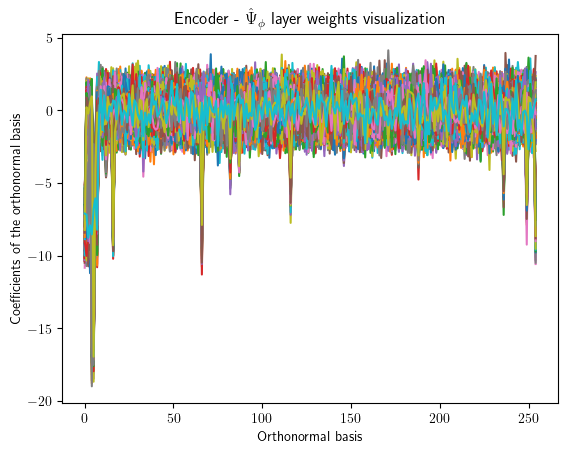

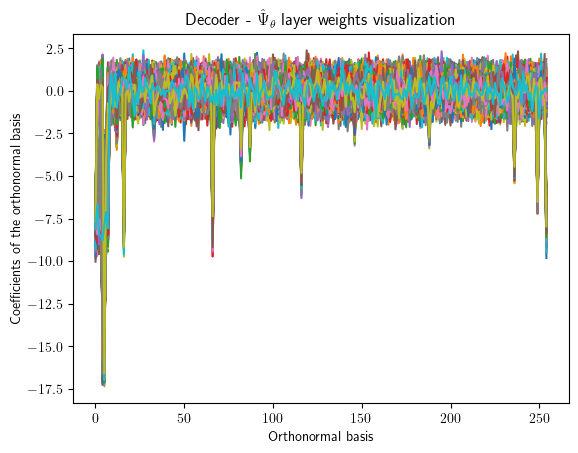

In [7]:
# Weights visualization of deterministic part estimated by both encoder and decoder for all samples excluding the bias (we disable saving option)
discard_bias = True
weights_visualization(encoder, decoder, [i for i in range(nb_samples)], discard_bias=discard_bias, saving=False, path=None, filename=None)

We can visually compare the extracted leakage models with the true leakage model $\Psi$.

To compute $\Psi$, we use $\texttt{orthonormal\_basis\_computation\_true\_coeffs}$ function (see $\texttt{cVAE\_OSM\_tools.py}$ file).

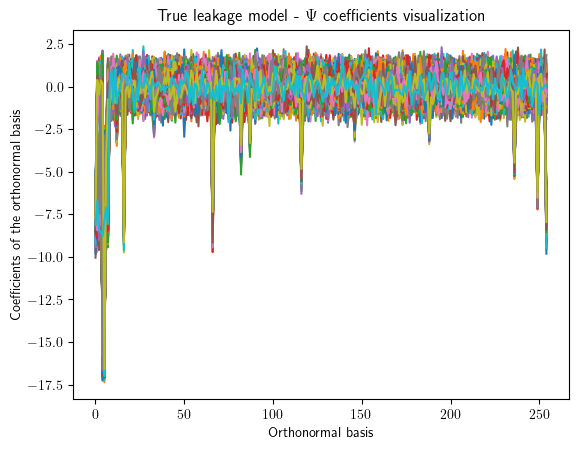

In [8]:
# Computation of an estimation of the real orthonormal basis coefficients
psi = orthonormal_basis_computation_true_coeffs(traces, targeted_variables[:, targeted_byte], max_nb_monomials_interactions)

# Plot of the true leakage model for all samples excluding the bias
for i in range(psi.shape[0]):
    plt.plot(psi[i,int(discard_bias):])

plt.title(r'True leakage model - $\Psi$ coefficients visualization')
plt.xlabel('Orthonormal basis')
plt.ylabel('Coefficients of the orthonormal basis')
plt.show()

We can also compare more formally leakage models $\hat{\Psi}_\phi$ and $\hat{\Psi}_\theta$ extracted by the model with the true leakage model $\Psi$ by using mean squared error (MSE).

In [9]:
# Getting back from the encoder and decoder the weights i.e. estimated deterministic parts
psi_phi = encoder.get_layer('psi_layer_encoder').weights[0].numpy()
psi_phi = psi_phi.T
psi_theta = decoder.get_layer('psi_layer_decoder').weights[0].numpy()
psi_theta = psi_theta.T

# Computation of MSE 
psi_phi_difference = np.subtract(psi, psi_phi)
psi_theta_difference = np.subtract(psi, psi_theta)
psi_phi_mse = np.mean(np.square(psi_phi_difference))
psi_theta_mse = np.mean(np.square(psi_theta_difference))

print("MSE(Psi, Psi_phi) = %.5f" % psi_phi_mse)
print("MSE(Psi, Psi_theta) = %.5f" % psi_theta_mse)

MSE(Psi, Psi_phi) = 0.45615
MSE(Psi, Psi_theta) = 0.00010


Regarding $\boldsymbol{\Sigma}_\phi$, we can compute the approximation error for each sample.

In [10]:
# Getting back from the encoder the weights i.e. the inverse of the variance for each sample
encoder_inverse_variances = encoder.get_layer('z_mean').weights[0].numpy()
encoder_variances = 1/encoder_inverse_variances

# Computation of approximation errors
true_variances = sigmas**2
approx_errors = np.abs(np.subtract(true_variances,encoder_variances)/true_variances)
percent_errors = 100 * approx_errors

print("Mean of percent approximation errors: %.2f%%" % np.mean(percent_errors))


Mean of percent approximation errors: 6.41%


All the results obtained through this notebook are in line with those reported in Section 5.1.5 (paragraph Impact of PoIs in leakage model extraction).

We observe that cVAE-OSM is able to correctly extract leakage model and variance of traces, even when considering a single PoI. We obtain a low MSE value for $\Psi_\phi$ and  $\Psi_\theta$ estimation. Moreover, the average of percent approximation errors does not exceed $7\%$ for $\boldsymbol{\Sigma}_\phi$ estimation.

Hence, this means that cVAE-OSM is able to extract leakage model regardless of the number of PoIs considered.

## Impact of $D$ in cVAE-OSM weights convergence <a class='anchor' id='exp-2'></a>

The aim of this experiment is to assess the impact of $D$ in cVAE-OSM weights convergence. To do so, we generate traces with $D<100$. Then, we create and train a cVAE-OSM model.

Finally, we assess cVAE-OSM leakage model extraction by visualizing leakage models $\hat{\Psi}_\phi$ and $\hat{\Psi}_\theta$ extracted by the model and computing mean squared errors (MSE) for both estimated leakage models. 

Regarding $\boldsymbol{\Sigma}_\phi$, we compute mean approximation error to evaluate its convergence.

### Step 1: Traces generation <a class='anchor' id='exp-2-step-1'></a>

The generation of traces is done using a function called $\texttt{generate\_traces}$, available in $\texttt{generate\_traces.py}$ file. 

In the following example, we generate $20,000$ traces of $D=10$ samples such that $1$ sample is a PoI. We consider the fourth scenario with a isotropic Gaussian noise of parameters $\mu=0$ and $\sigma=5$.
The targeted byte is $0$ and the key is fixed. We set the seed to $42$ to have reproductible results. 

In [11]:
# Traces generation
targeted_byte = 0

traces, plaintexts, keys, targeted_variables, sigmas = generate_traces(nb_traces=20000, nb_samples=10, nb_poi=1, mu=0, sigmas=np.array([5]), targeted_byte=targeted_byte, \
                        isotropic_noise=True, scenario='scenario_4', key_fixed=True, seed=42)

print("Traces generated \U00002705")

Traces generated ✅


Here is an example of generated traces.

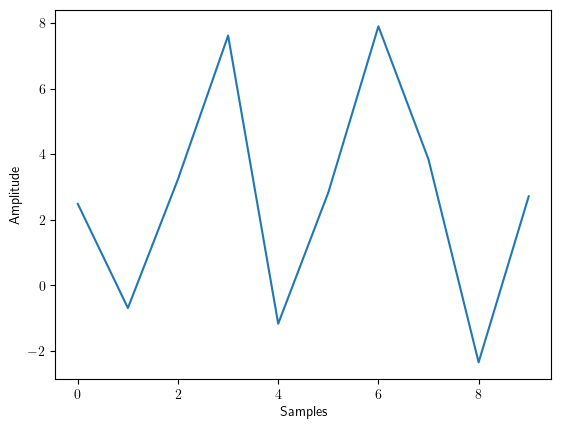

In [12]:
# Plot of a trace
plt.plot(traces[0,:])
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

### Step 2: Instanciation of a cVAE-OSM model <a class='anchor' id='exp-2-step-2'></a>

After generating traces, we instanciate a cVAE-OSM model. As for traces generation, to enable reproductible results, we set the seed to a fixed value. In this case, we choose $\texttt{seed}=42$.

Considering a learning rate set to $0.005$, we instanciate a cVAE-OSM by calling $\texttt{cVAE}$ class (see $\texttt{cVAE\_OSM\_model.py}$ file) and compile the model.

In [13]:
# Instanciation of encoder and decoder
nb_samples = traces.shape[1]
learning_rate = 0.001
max_nb_monomials_interactions, len_basis = 8, 256

encoder = define_encoder(input_size=nb_samples, len_basis=len_basis, is_deterministic=True, seed=42)
decoder = define_decoder(input_size=nb_samples, len_basis=len_basis, is_deterministic=True, seed=42)

# Instanciation of cVAE-OSM model
cVAE_OSM = cVAE(encoder, decoder)

# Compilation of cVAE-OSM model
cVAE_OSM.compile(optimizer=keras.optimizers.Adam(learning_rate))

print("Model created \U00002705")

Model created ✅


### Step 3: Training of cVAE-OSM model <a class='anchor' id='exp-2-step-3'></a>

Once the model is created, we train our model using simulated traces and the projection of targeted variables into the orthonormal basis.

The projection of targeted variables onto Guilley *et al.* basis is computed using $\texttt{orthonormal\_basis\_projection}$ function, which is available in $\texttt{cVAE\_OSM\_tools.py}$ file. We consider all bits interactions, thus $\texttt{len\_basis}=256$.

In [14]:
# Projection of target variables onto Guilley etal. orthonormal basis
# We consider the full basis (len_basis=256) i.e. all the monomials len_basis=256
# One can also consider other configurations
# For example, when considering only the monomials individually i.e. without interactions between them, len_basis=9
projection_targeted_variables = orthonormal_basis_projection(targeted_variables[:, targeted_byte], max_nb_monomials_interactions, len_basis)

print("Projection done \U00002705")

Projection done ✅


Then, training is done for $200$ epochs using a batch size set to $8$.

In [15]:
# cVAE-OSM training
batch_size = 8
epochs = 200

cVAE_OSM.fit([traces, projection_targeted_variables], epochs=epochs, batch_size=batch_size)

print("Training done \U00002705")

Epoch 1/200
2500/2500 [==============================] - 4s 1ms/step - ELBO loss: 974.3666 - reconstruction_loss: 61.5905 - kl_loss: 373.9173
Epoch 2/200
2500/2500 [==============================] - 3s 1ms/step - ELBO loss: 31.0711 - reconstruction_loss: 30.5585 - kl_loss: 0.4876
Epoch 3/200
2500/2500 [==============================] - 3s 1ms/step - ELBO loss: 31.0731 - reconstruction_loss: 30.5513 - kl_loss: 0.4864
Epoch 4/200
2500/2500 [==============================] - 3s 1ms/step - ELBO loss: 31.0461 - reconstruction_loss: 30.5419 - kl_loss: 0.4894
Epoch 5/200
2500/2500 [==============================] - 4s 1ms/step - ELBO loss: 30.9963 - reconstruction_loss: 30.5223 - kl_loss: 0.4888
Epoch 6/200
2500/2500 [==============================] - 4s 1ms/step - ELBO loss: 30.9989 - reconstruction_loss: 30.5049 - kl_loss: 0.4915
Epoch 7/200
2500/2500 [==============================] - 3s 1ms/step - ELBO loss: 30.9770 - reconstruction_loss: 30.4846 - kl_loss: 0.4888
Epoch 8/200
2500/2500 [=

### Step 4: Visualization of leakage models extracted by the model <a class='anchor' id='exp-2-step-4'></a>

Finally, we can visualize the deterministic parts estimated by our model *i.e.* $\hat{\Psi}_\phi$ and $\hat{\Psi}_\theta$, and compare them to the true leakage model.

This visualization is done using $\texttt{weights\_visualization}$ function (see $\texttt{cVAE\_OSM\_tools.py}$ file).

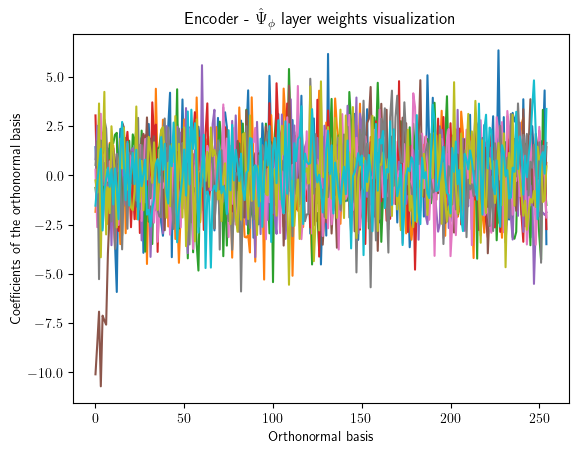

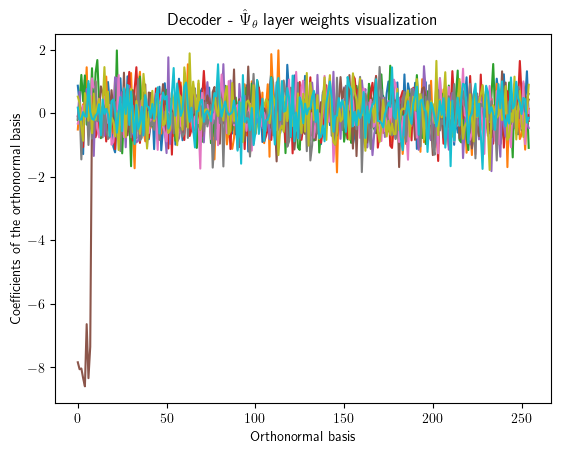

In [16]:
# Weights visualization of deterministic part estimated by both encoder and decoder for all samples excluding the bias (we disable saving option)
discard_bias = True
weights_visualization(encoder, decoder, [i for i in range(nb_samples)], discard_bias=discard_bias, saving=False, path=None, filename=None)

We can visually compare the extracted leakage models with the true leakage model $\Psi$.

To compute $\Psi$, we use $\texttt{orthonormal\_basis\_computation\_true\_coeffs}$ function (see $\texttt{cVAE\_OSM\_tools.py}$ file).

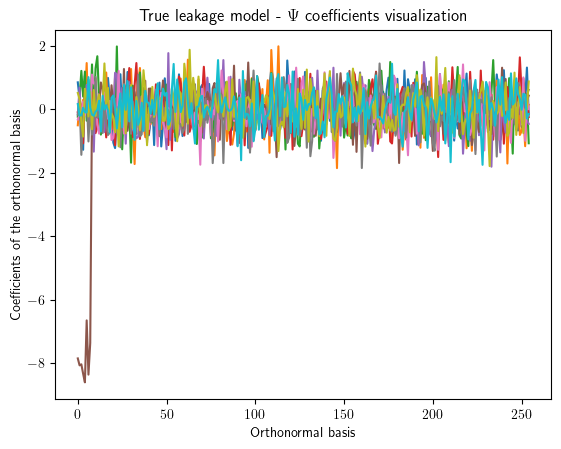

In [17]:
# Computation of an estimation of the real orthonormal basis coefficients
psi = orthonormal_basis_computation_true_coeffs(traces, targeted_variables[:, targeted_byte], max_nb_monomials_interactions)

# Plot of the true leakage model for all samples excluding the bias
for i in range(psi.shape[0]):
    plt.plot(psi[i,int(discard_bias):])

plt.title(r'True leakage model - $\Psi$ coefficients visualization')
plt.xlabel('Orthonormal basis')
plt.ylabel('Coefficients of the orthonormal basis')
plt.show()

We can also compare more formally leakage models $\hat{\Psi}_\phi$ and $\hat{\Psi}_\theta$ extracted by the model with the true leakage model $\Psi$ by using mean squared error (MSE).

In [18]:
# Getting back from the encoder and decoder the weights i.e. estimated deterministic parts
psi_phi = encoder.get_layer('psi_layer_encoder').weights[0].numpy()
psi_phi = psi_phi.T
psi_theta = decoder.get_layer('psi_layer_decoder').weights[0].numpy()
psi_theta = psi_theta.T

# Computation of MSE 
psi_phi_difference = np.subtract(psi, psi_phi)
psi_theta_difference = np.subtract(psi, psi_theta)
psi_phi_mse = np.mean(np.square(psi_phi_difference))
psi_theta_mse = np.mean(np.square(psi_theta_difference))

print("MSE(Psi, Psi_phi) = %.5f" % psi_phi_mse)
print("MSE(Psi, Psi_theta) = %.5f" % psi_theta_mse)

MSE(Psi, Psi_phi) = 2.86783
MSE(Psi, Psi_theta) = 0.00010


Regarding $\boldsymbol{\Sigma}_\phi$, we can compute the approximation error for each sample.

In [19]:
# Getting back from the encoder the weights i.e. the inverse of the variance for each sample
encoder_inverse_variances = encoder.get_layer('z_mean').weights[0].numpy()
encoder_variances = 1/encoder_inverse_variances

# Computation of approximation errors
true_variances = sigmas**2
approx_errors = np.abs(np.subtract(true_variances,encoder_variances)/true_variances)
percent_errors = 100 * approx_errors

print("Mean of percent approximation errors: %.2f%%" % np.mean(percent_errors))


Mean of percent approximation errors: 10.19%


All the results obtained through this notebook are in line with those reported in Section 5.1.5 (paragraph Impact of $D$ on convergence of cVAE-OSM weights).

We observe that cVAE-OSM is able to correctly extract leakage model and variance of traces, even when considering $D=10$. However, we notice that since $D<100$, 
the approximation by a Gaussian distribution of the true distribution of $\mathbf{\tilde{T}}$ namely a $\chi^2$-distribution in KL-divergence term of the ELBO loss induces errors on leakage model $\Psi_\phi$ and variance $\boldsymbol{\Sigma}_\phi$ estimated by the encoder. 

Nevertheless, results obtained allow us to still conclude that cVAE-OSM is able to correctly extract leakage model and variance even when $D<100$.

## Impact of basis size<a class='anchor' id='exp-3'></a>

The aim of this experiment is to assess the impact of basis size in cVAE-OSM weights convergence. To do so, we generate traces following a scenario in which bits leak independently *i.e.* no bit interactions leak. Then, we create and train a cVAE-OSM model considering a poor choice of basis size (*i.e.* we train a cVAE-OSM model considering all bits interactions).

Finally, we assess cVAE-OSM leakage model extraction by visualizing leakage models $\hat{\Psi}_\phi$ and $\hat{\Psi}_\theta$ extracted by the model and computing mean squared errors (MSE) for both estimated leakage models. 

Regarding $\boldsymbol{\Sigma}_\phi$, we compute mean approximation error to evaluate its convergence.

### Step 1: Traces generation <a class='anchor' id='exp-3-step-1'></a>

The generation of traces is done using a function called $\texttt{generate\_traces}$, available in $\texttt{generate\_traces.py}$ file. 

In the following example, we generate $20,000$ traces of $150$ samples such that $10\%$ are PoIs. We consider the first scenario (Hamming Weight leakage model) with a isotropic Gaussian noise of parameters $\mu=0$ and $\sigma=5$.
The targeted byte is $0$ and the key is fixed. We set the seed to $42$ to have reproductible results. 

In [20]:
# Traces generation
targeted_byte = 0

traces, plaintexts, keys, targeted_variables, sigmas = generate_traces(nb_traces=20000, nb_samples=150, nb_poi=15, mu=0, sigmas=np.array([5]), targeted_byte=targeted_byte, \
                        isotropic_noise=True, scenario='scenario_1', key_fixed=True, seed=42)

print("Traces generated \U00002705")

Traces generated ✅


Here is an example of generated traces.

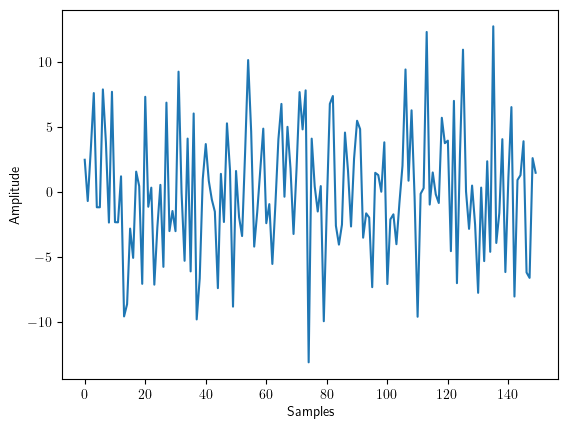

In [21]:
# Plot of a trace
plt.plot(traces[0,:])
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

### Step 2: Instanciation of a cVAE-OSM model <a class='anchor' id='exp-3-step-2'></a>

After generating traces, we instanciate a cVAE-OSM model. As for traces generation, to enable reproductible results, we set the seed to a fixed value. In this case, we choose $\texttt{seed}=42$.

Considering a learning rate set to $0.0001$, we instanciate a cVAE-OSM by calling $\texttt{cVAE}$ class (see $\texttt{cVAE\_OSM\_model.py}$ file) and compile the model.

In [22]:
# Instanciation of encoder and decoder
nb_samples = traces.shape[1]
learning_rate = 0.0001
max_nb_monomials_interactions, len_basis = 8, 256

encoder = define_encoder(input_size=nb_samples, len_basis=len_basis, is_deterministic=True, seed=42)
decoder = define_decoder(input_size=nb_samples, len_basis=len_basis, is_deterministic=True, seed=42)

# Instanciation of cVAE-OSM model
cVAE_OSM = cVAE(encoder, decoder)

# Compilation of cVAE-OSM model
cVAE_OSM.compile(optimizer=keras.optimizers.Adam(learning_rate))

print("Model created \U00002705")

Model created ✅


### Step 3: Training of cVAE-OSM model <a class='anchor' id='exp-3-step-3'></a>

Once the model is created, we train our model using simulated traces and the projection of targeted variables into the orthonormal basis.

The projection of targeted variables onto Guilley *et al.* basis is computed using $\texttt{orthonormal\_basis\_projection}$ function, which is available in $\texttt{cVAE\_OSM\_tools.py}$ file. We consider all bits interactions, thus $\texttt{len\_basis}=256$. Consequently this implies that cVAE-OSM training is done with a poor basis choice as $\texttt{len\_basis}=256>9$.

In [23]:
# Projection of target variables onto Guilley etal. orthonormal basis
# We consider the full basis (len_basis=256) i.e. all the monomials len_basis=256
# One can also consider other configurations
# For example, when considering only the monomials individually i.e. without interactions between them, len_basis=9
projection_targeted_variables = orthonormal_basis_projection(targeted_variables[:, targeted_byte], max_nb_monomials_interactions, len_basis)

print("Projection done \U00002705")

Projection done ✅


Then, training is done for $200$ epochs using a batch size set to $8$.

In [24]:
# cVAE-OSM training
batch_size = 8
epochs = 200

cVAE_OSM.fit([traces, projection_targeted_variables], epochs=epochs, batch_size=batch_size)

print("Training done \U00002705")

Epoch 1/200
2500/2500 [==============================] - 4s 1ms/step - ELBO loss: 24687.5788 - reconstruction_loss: 1940.3406 - kl_loss: 20124.5078
Epoch 2/200
2500/2500 [==============================] - 3s 1ms/step - ELBO loss: 15028.4866 - reconstruction_loss: 1544.8693 - kl_loss: 11613.7412
Epoch 3/200
2500/2500 [==============================] - 3s 1ms/step - ELBO loss: 8176.1367 - reconstruction_loss: 1176.9635 - kl_loss: 5709.9141
Epoch 4/200
2500/2500 [==============================] - 3s 1ms/step - ELBO loss: 3668.0855 - reconstruction_loss: 843.9809 - kl_loss: 2067.4270
Epoch 5/200
2500/2500 [==============================] - 3s 1ms/step - ELBO loss: 1246.7981 - reconstruction_loss: 579.5167 - kl_loss: 378.0110
Epoch 6/200
2500/2500 [==============================] - 3s 1ms/step - ELBO loss: 496.7040 - reconstruction_loss: 464.3813 - kl_loss: 10.2325
Epoch 7/200
2500/2500 [==============================] - 3s 1ms/step - ELBO loss: 458.8477 - reconstruction_loss: 458.2112 - kl

### Step 4: Visualization of leakage models extracted by the model <a class='anchor' id='exp-3-step-4'></a>

Finally, we can visualize the deterministic parts estimated by our model *i.e.* $\hat{\Psi}_\phi$ and $\hat{\Psi}_\theta$, and compare them to the true leakage model.

This visualization is done using $\texttt{weights\_visualization}$ function (see $\texttt{cVAE\_OSM\_tools.py}$ file).

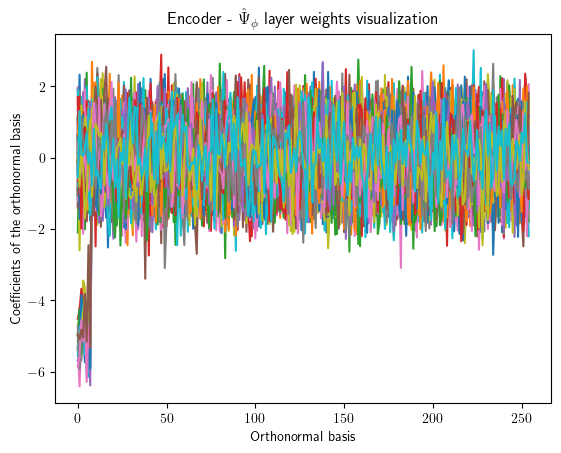

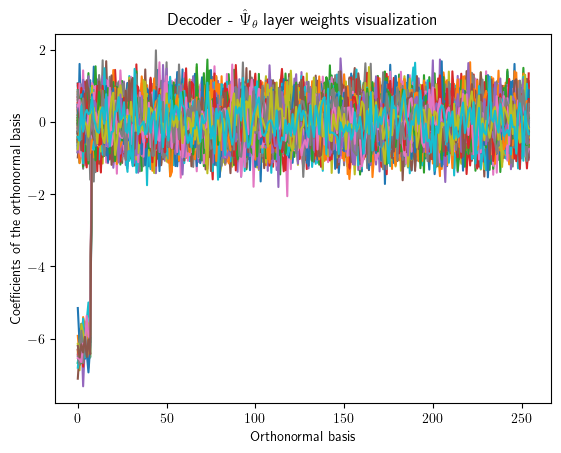

In [25]:
# Weights visualization of deterministic part estimated by both encoder and decoder for all samples excluding the bias (we disable saving option)
discard_bias = True
weights_visualization(encoder, decoder, [i for i in range(nb_samples)], discard_bias=discard_bias, saving=False, path=None, filename=None)

We can visually compare the extracted leakage models with the true leakage model $\Psi$.

To compute $\Psi$, we use $\texttt{orthonormal\_basis\_computation\_true\_coeffs}$ function (see $\texttt{cVAE\_OSM\_tools.py}$ file).

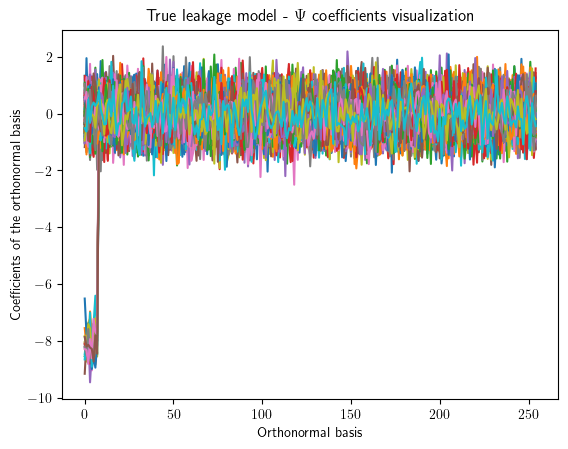

In [26]:
# Computation of an estimation of the real orthonormal basis coefficients
psi = orthonormal_basis_computation_true_coeffs(traces, targeted_variables[:, targeted_byte], max_nb_monomials_interactions)

# Plot of the true leakage model for all samples excluding the bias
for i in range(psi.shape[0]):
    plt.plot(psi[i,int(discard_bias):])

plt.title(r'True leakage model - $\Psi$ coefficients visualization')
plt.xlabel('Orthonormal basis')
plt.ylabel('Coefficients of the orthonormal basis')
plt.show()

We can also compare more formally leakage models $\hat{\Psi}_\phi$ and $\hat{\Psi}_\theta$ extracted by the model with the true leakage model $\Psi$ by using mean squared error (MSE).

In [27]:
# Getting back from the encoder and decoder the weights i.e. estimated deterministic parts
psi_phi = encoder.get_layer('psi_layer_encoder').weights[0].numpy()
psi_phi = psi_phi.T
psi_theta = decoder.get_layer('psi_layer_decoder').weights[0].numpy()
psi_theta = psi_theta.T

# Computation of MSE 
psi_phi_difference = np.subtract(psi, psi_phi)
psi_theta_difference = np.subtract(psi, psi_theta)
psi_phi_mse = np.mean(np.square(psi_phi_difference))
psi_theta_mse = np.mean(np.square(psi_theta_difference))

print("MSE(Psi, Psi_phi) = %.5f" % psi_phi_mse)
print("MSE(Psi, Psi_theta) = %.5f" % psi_theta_mse)

MSE(Psi, Psi_phi) = 1.59482
MSE(Psi, Psi_theta) = 0.25269


Regarding $\boldsymbol{\Sigma}_\phi$, we can compute the approximation error for each sample.

In [28]:
# Getting back from the encoder the weights i.e. the inverse of the variance for each sample
encoder_inverse_variances = encoder.get_layer('z_mean').weights[0].numpy()
encoder_variances = 1/encoder_inverse_variances

# Computation of approximation errors
true_variances = sigmas**2
approx_errors = np.abs(np.subtract(true_variances,encoder_variances)/true_variances)
percent_errors = 100 * approx_errors

print("Mean of percent approximation errors: %.2f%%" % np.mean(percent_errors))


Mean of percent approximation errors: 3.44%


All the results obtained through this notebook are in line with those reported in Section 5.1.5 (paragraph Impact of basis size).

We observe that cVAE-OSM is able to correctly extract leakage model and variance of traces, even when considering a wrong choice of basis size. Indeed, we obtain a low MSE value for $\Psi_\phi$ and  $\Psi_\theta$ estimation. Moreover, the average of percent approximation errors does not exceed $4\%$ for $\boldsymbol{\Sigma}_\phi$ estimation.

Thus, this means that cVAE-OSM is robust to a poor choice of basis size as it is still able to correctly extract leakage model and variance of traces.